In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# load data; filter by product and timeframe
file_names = [
	".\\r3_d0.csv",
	".\\r3_d1.csv",
	".\\r3_d2.csv",
]
merged_file_name = ".\\merged_r3.csv"

if not Path(merged_file_name).exists():
	parts = []
	for i, fn in enumerate(file_names):
		part = pd.read_csv(fn, delimiter=";")
		part["timestamp"] = part["timestamp"] + i * 1_000_000
		parts.append(part)

	pd.concat(parts, ignore_index=True).to_csv(merged_file_name, sep=";", index=False)

df = pd.read_csv(merged_file_name, delimiter=";")

HYDROGEL = df[df['product'] == 'HYDROGEL_PACK']
VELVETFRUIT = df[df['product'] == 'VELVETFRUIT_EXTRACT']

df = HYDROGEL
low, high = map(int, input().split())
# low, high = (0, 3000000)
df = df[(df['timestamp'] >= low) & (df['timestamp'] <= high)]
df = df[(df['bid_price_1'].notna()) & (df['ask_price_1'].notna())]
print(df['bid_price_1'].std())
print(df['ask_price_1'].std())

31.918853800794405
31.968126113862173


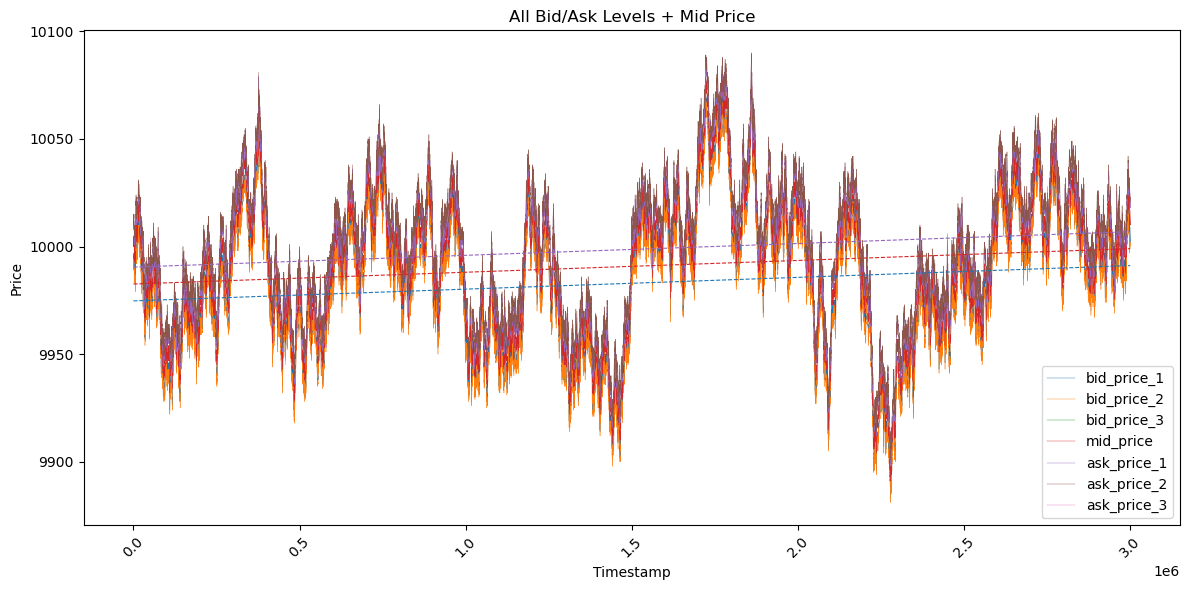

In [21]:
import numpy as np


# plot 7 price levels
# plt.figure(figsize=(300, 30))
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['bid_price_1'], label='bid_price_1', lw = 0.3)
plt.plot(df['timestamp'], df['bid_price_2'], label='bid_price_2', lw = 0.3)
plt.plot(df['timestamp'], df['bid_price_3'], label='bid_price_3', lw = 0.3)
plt.plot(df['timestamp'], df['mid_price'], label='mid_price', lw = 0.3)
plt.plot(df['timestamp'], df['ask_price_1'], label='ask_price_1', lw = 0.3)
plt.plot(df['timestamp'], df['ask_price_2'], label='ask_price_2', lw = 0.3)
plt.plot(df['timestamp'], df['ask_price_3'], label='ask_price_3', lw = 0.3)
x = df['timestamp'].to_numpy()
for y, c in [
	(df['bid_price_1'], 'C0'),
	(df['mid_price'], 'C3'),
	(df['ask_price_1'], 'C4'),
]:
	mask = y.notna()
	m, b = np.polyfit(x[mask], y[mask], 1)
	plt.plot(x, m * x + b, linestyle='--', linewidth=0.8, color=c)

plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.title('All Bid/Ask Levels + Mid Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

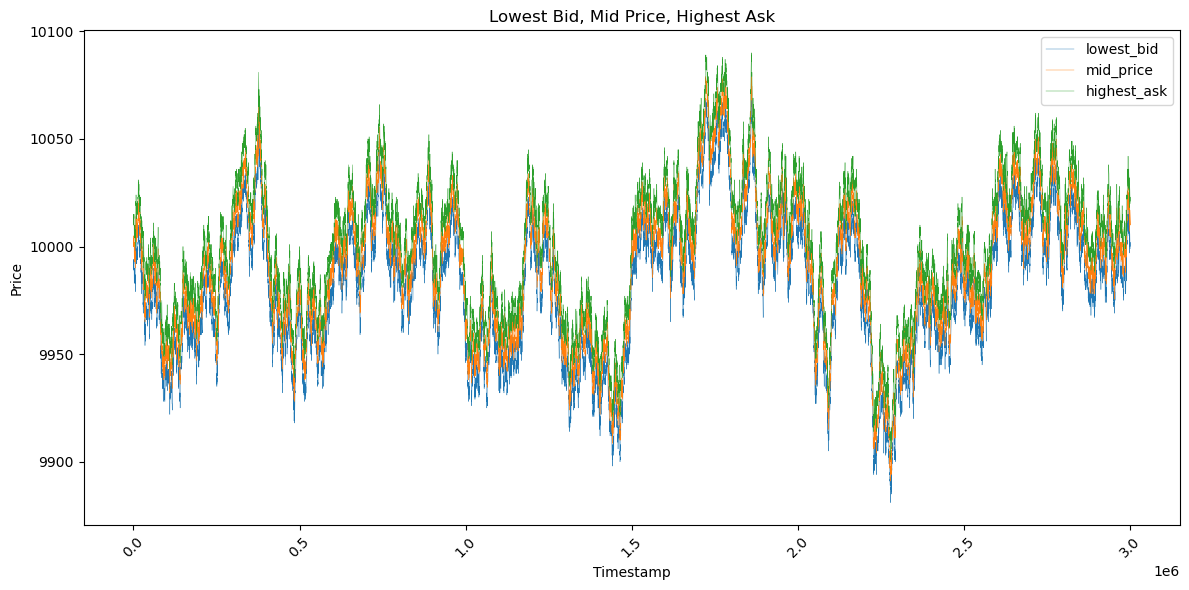

In [22]:

# lowest bid, mid price, highest ask
lowest_bid = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].min(axis=1)
highest_ask = df[['ask_price_1', 'ask_price_2', 'ask_price_3']].max(axis=1)
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], lowest_bid, label='lowest_bid', lw = 0.3)
plt.plot(df['timestamp'], df['mid_price'], label='mid_price', lw = 0.3)
plt.plot(df['timestamp'], highest_ask, label='highest_ask', lw = 0.3)
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.title('Lowest Bid, Mid Price, Highest Ask')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

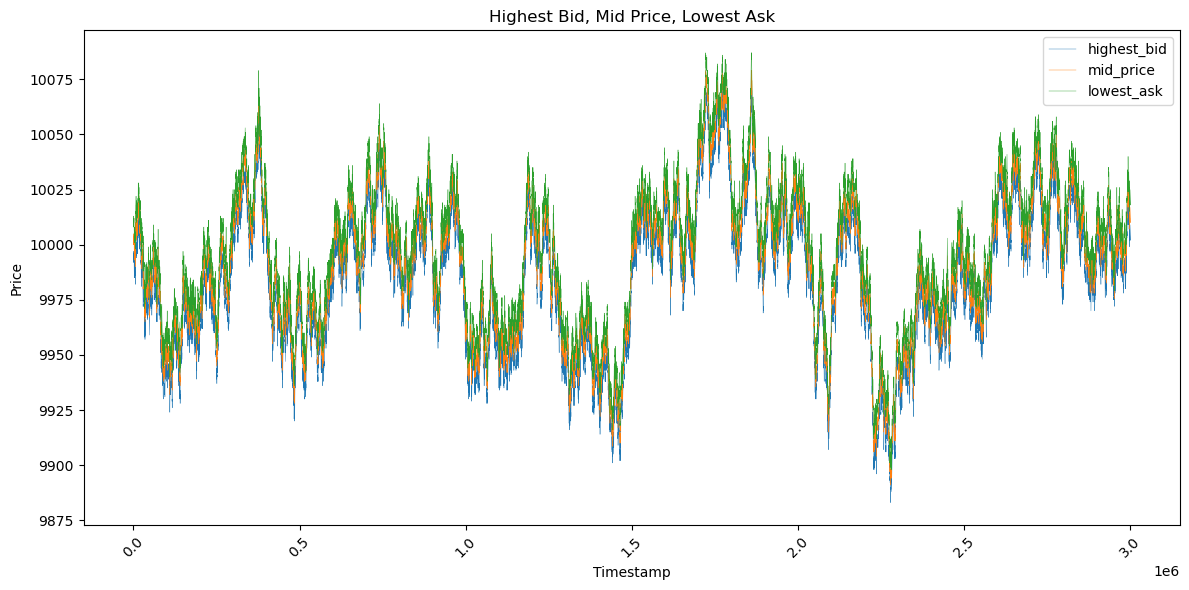

In [23]:

# highest bid, mid price, lowest ask
highest_bid = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].max(axis=1)
lowest_ask = df[['ask_price_1', 'ask_price_2', 'ask_price_3']].min(axis=1)
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], highest_bid, label='highest_bid', lw = 0.3)
plt.plot(df['timestamp'], df['mid_price'], label='mid_price', lw = 0.3)
plt.plot(df['timestamp'], lowest_ask, label='lowest_ask', lw = 0.3)
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.title('Highest Bid, Mid Price, Lowest Ask')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

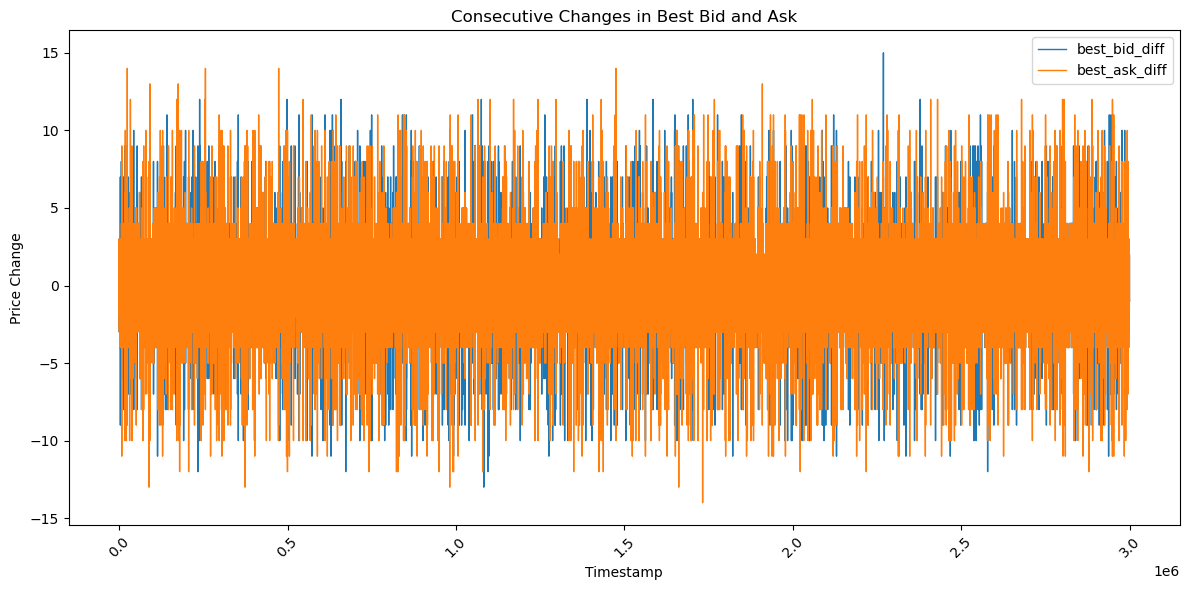

In [24]:
# plot differences in best bid + ask to find signal --> +/- 2.5!
best_bid = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].max(axis=1)
best_ask = df[['ask_price_1', 'ask_price_2', 'ask_price_3']].min(axis=1)
best_bid_diff = best_bid.diff()
best_ask_diff = best_ask.diff()
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], best_bid_diff, label='best_bid_diff', lw=1)
plt.plot(df['timestamp'], best_ask_diff, label='best_ask_diff', lw=1)
plt.xlabel('Timestamp')
plt.ylabel('Price Change')
plt.title('Consecutive Changes in Best Bid and Ask')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

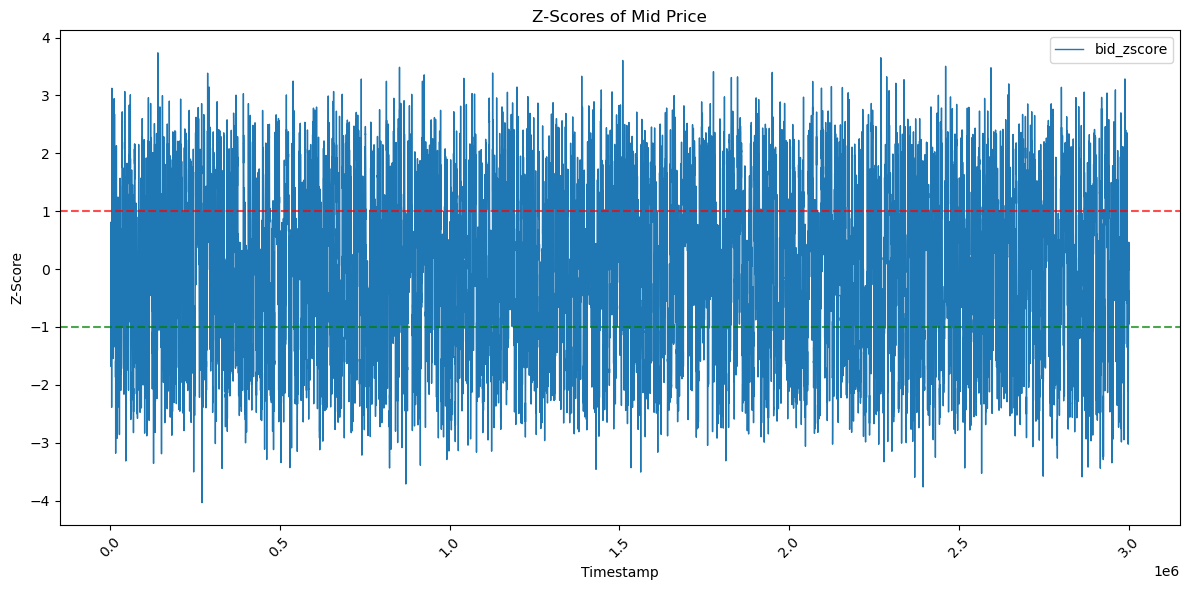

In [25]:
# best bid and ask
best_bid = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].max(axis=1)
best_ask = df[['ask_price_1', 'ask_price_2', 'ask_price_3']].min(axis=1)
mid_price = (best_bid + best_ask) / 2

# rolling z-scores
window = 30  # adjust as needed
mid_mean = mid_price.rolling(window).mean()
mid_std = mid_price.rolling(window).std()
z_score = (mid_price - mid_mean) / mid_std

# plot z-scores
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], z_score, label='bid_zscore', lw=1)
plt.axhline(1, linestyle='--', color='red', alpha=0.7)
plt.axhline(-1, linestyle='--', color='green', alpha=0.7)
plt.xlabel('Timestamp')
plt.ylabel('Z-Score')
plt.title('Z-Scores of Mid Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

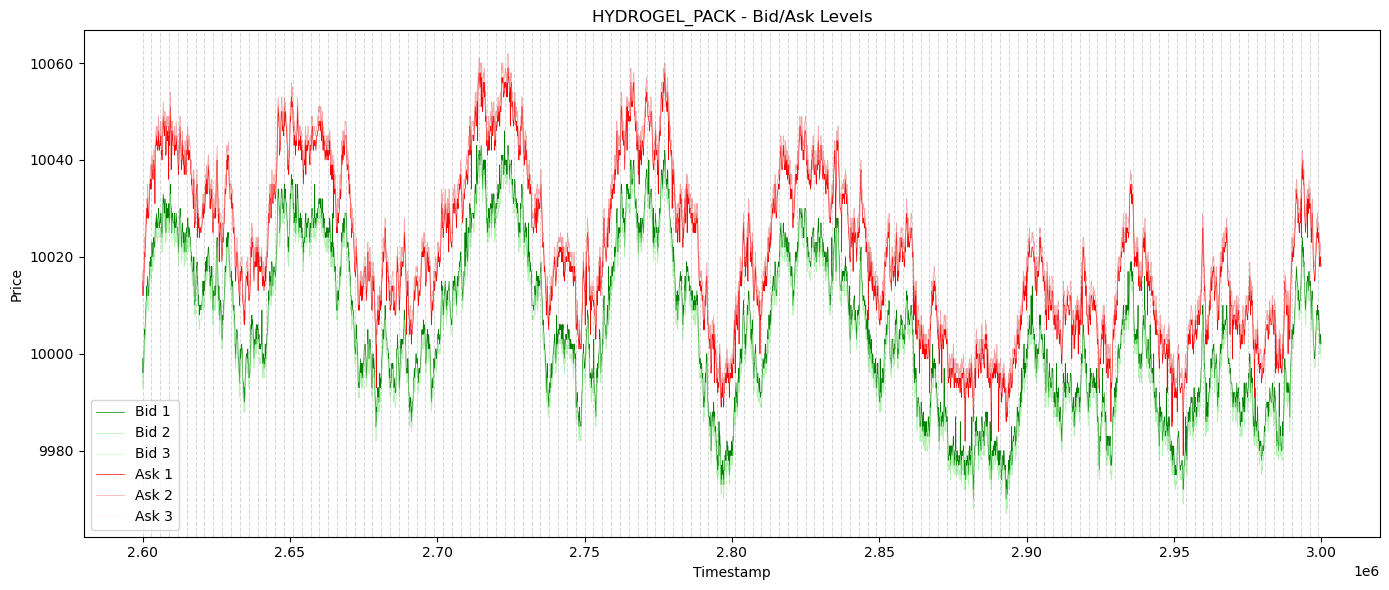

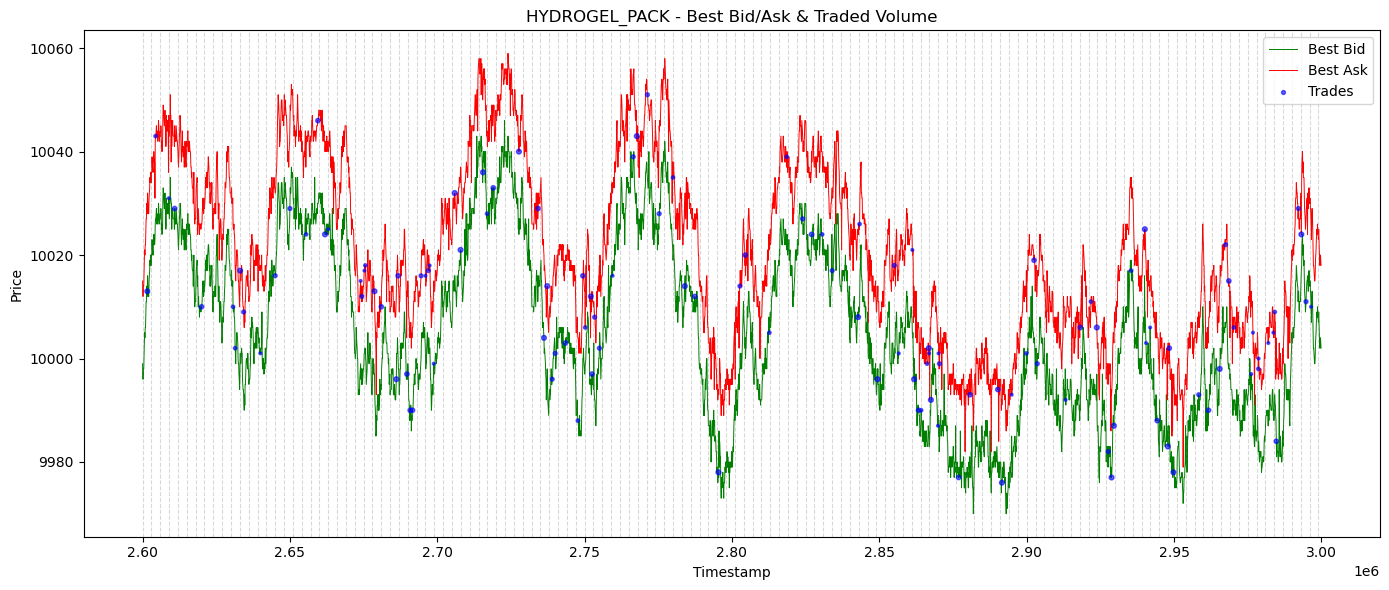

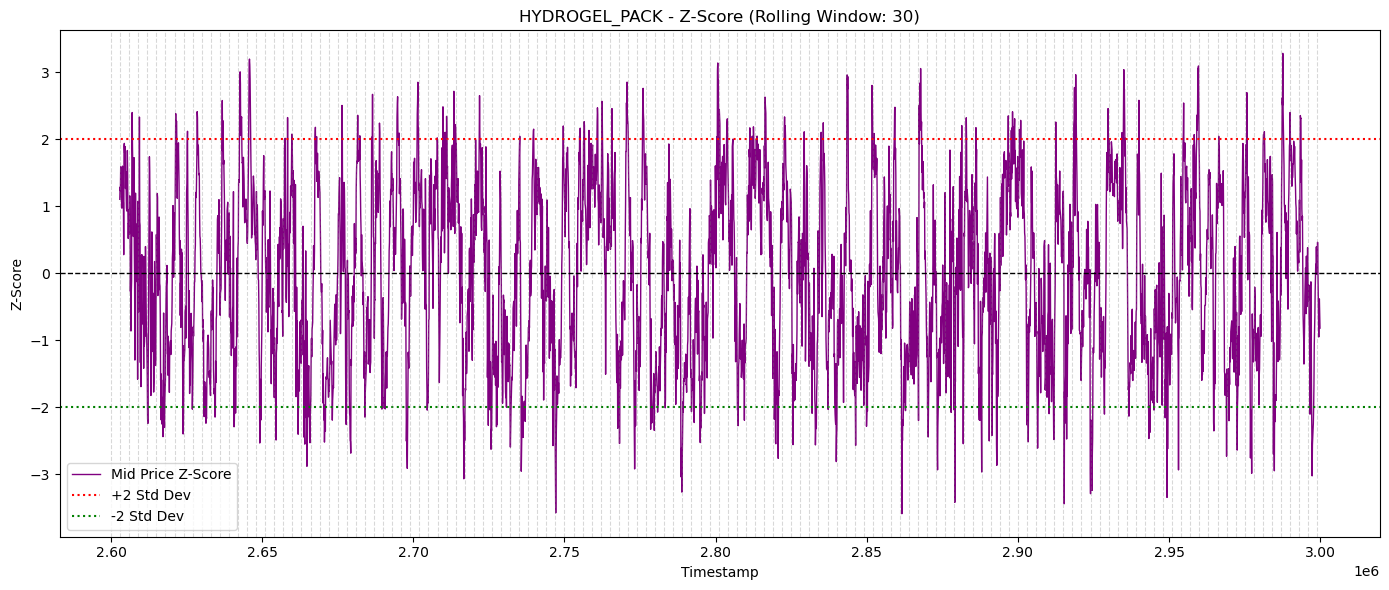

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# --- 1. Load and Merge Order Book Data ---
ob_files = [".\\r3_d0.csv", ".\\r3_d1.csv", ".\\r3_d2.csv"]
merged_ob_file = ".\\merged_r3.csv"
if not Path(merged_ob_file).exists():
    parts = []
    for i, fn in enumerate(ob_files):
        if Path(fn).exists():
            part = pd.read_csv(fn, delimiter=";")
            part["timestamp"] = part["timestamp"] + i * 1_000_000
            parts.append(part)
    if parts:
        pd.concat(parts, ignore_index=True).to_csv(merged_ob_file, sep=";", index=False)
df_ob = pd.read_csv(merged_ob_file, delimiter=";")

# --- 2. Load and Merge Trades Data ---
tr_files = [".\\tr3_d0.csv", ".\\tr3_d1.csv", ".\\tr3_d2.csv"]
merged_tr_file = ".\\merged_tr3.csv"
if not Path(merged_tr_file).exists():
    parts = []
    for i, fn in enumerate(tr_files):
        if Path(fn).exists():
            part = pd.read_csv(fn, delimiter=";")
            part["timestamp"] = part["timestamp"] + i * 1_000_000
            parts.append(part)
    if parts:
        pd.concat(parts, ignore_index=True).to_csv(merged_tr_file, sep=";", index=False)

if Path(merged_tr_file).exists():
    df_tr = pd.read_csv(merged_tr_file, delimiter=";")
else:
    df_tr = pd.DataFrame()

# --- 3. Configuration ---
TARGET_PRODUCT = 'HYDROGEL_PACK'  # Change to your target product
USE_ROLLING_STATS = True  # Set False to use overall mean/stddev
ROLLING_WINDOW = 30       # Window size if USE_ROLLING_STATS is True

# Set min and max timestamps (None for no limit)
MIN_TIMESTAMP = 2600000  # e.g., 500000
MAX_TIMESTAMP = None  # e.g., 1500000

# --- Vertical Window Lines Configuration ---
SHOW_WINDOW_LINES = True
WINDOW_STEP = ROLLING_WINDOW * 100
# --------------------------------------------

# Filter Data
prod_ob = df_ob[df_ob['product'] == TARGET_PRODUCT].copy()
prod_ob = prod_ob[(prod_ob['bid_price_1'].notna()) & (prod_ob['ask_price_1'].notna())].copy()

if MIN_TIMESTAMP is not None:
    prod_ob = prod_ob[prod_ob['timestamp'] >= MIN_TIMESTAMP]
if MAX_TIMESTAMP is not None:
    prod_ob = prod_ob[prod_ob['timestamp'] <= MAX_TIMESTAMP]

# Note: Trades data typically uses 'symbol' instead of 'product'
if not df_tr.empty and 'symbol' in df_tr.columns:
    prod_tr = df_tr[df_tr['symbol'] == TARGET_PRODUCT].copy()
elif not df_tr.empty and 'product' in df_tr.columns:
    prod_tr = df_tr[df_tr['product'] == TARGET_PRODUCT].copy()
else:
    prod_tr = pd.DataFrame()

if not prod_tr.empty:
    if MIN_TIMESTAMP is not None:
        prod_tr = prod_tr[prod_tr['timestamp'] >= MIN_TIMESTAMP]
    if MAX_TIMESTAMP is not None:
        prod_tr = prod_tr[prod_tr['timestamp'] <= MAX_TIMESTAMP]

# Compute Best Price / Mid Price
prod_ob['best_bid'] = prod_ob[['bid_price_1', 'bid_price_2', 'bid_price_3']].max(axis=1)
prod_ob['best_ask'] = prod_ob[['ask_price_1', 'ask_price_2', 'ask_price_3']].min(axis=1)
prod_ob['mid_price'] = (prod_ob['best_bid'] + prod_ob['best_ask']) / 2

def add_window_lines():
    if SHOW_WINDOW_LINES:
        t_start = prod_ob['timestamp'].min()
        t_end = prod_ob['timestamp'].max()
        # Generate lines based on step
        for t in range(int(t_start), int(t_end), WINDOW_STEP):
            plt.axvline(x=t, color='gray', linestyle='--', alpha=0.3, lw=0.8)

# === Graph 1: All Bid and Ask Prices ===
plt.figure(figsize=(14, 6))
plt.plot(prod_ob['timestamp'], prod_ob['bid_price_1'], label='Bid 1', color='g', lw=0.5)
plt.plot(prod_ob['timestamp'], prod_ob['bid_price_2'], label='Bid 2', color='lightgreen', lw=0.5, alpha=0.7)
plt.plot(prod_ob['timestamp'], prod_ob['bid_price_3'], label='Bid 3', color='palegreen', lw=0.5, alpha=0.5)
plt.plot(prod_ob['timestamp'], prod_ob['ask_price_1'], label='Ask 1', color='r', lw=0.5)
plt.plot(prod_ob['timestamp'], prod_ob['ask_price_2'], label='Ask 2', color='lightcoral', lw=0.5, alpha=0.7)
plt.plot(prod_ob['timestamp'], prod_ob['ask_price_3'], label='Ask 3', color='mistyrose', lw=0.5, alpha=0.5)
add_window_lines()
plt.title(f'{TARGET_PRODUCT} - Bid/Ask Levels')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

# === Graph 2: Best Bid/Ask + Trades Overlay ===
plt.figure(figsize=(14, 6))
plt.plot(prod_ob['timestamp'], prod_ob['best_bid'], label='Best Bid', color='g', lw=0.7)
plt.plot(prod_ob['timestamp'], prod_ob['best_ask'], label='Best Ask', color='r', lw=0.7)

if not prod_tr.empty:
    # Scatter plot for trades. Size can be proportional to quantity
    sizes = prod_tr['quantity'].abs() * 2 
    plt.scatter(prod_tr['timestamp'], prod_tr['price'], 
                c='blue', s=sizes, alpha=0.6, label='Trades', zorder=5)

add_window_lines()
plt.title(f'{TARGET_PRODUCT} - Best Bid/Ask & Traded Volume')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

# === Graph 3: Z-Score Plot ===
if USE_ROLLING_STATS:
    mean_series = prod_ob['mid_price'].rolling(ROLLING_WINDOW).mean()
    std_series = prod_ob['mid_price'].rolling(ROLLING_WINDOW).std()
else:
    mean_series = prod_ob['mid_price'].mean()
    std_series = prod_ob['mid_price'].std()

prod_ob['z_score'] = (prod_ob['mid_price'] - mean_series) / std_series

plt.figure(figsize=(14, 6))
plt.plot(prod_ob['timestamp'], prod_ob['z_score'], label='Mid Price Z-Score', color='purple', lw=1)
plt.axhline(0, color='black', lw=1, linestyle='--')
plt.axhline(2, color='red', lw=1.5, linestyle=':', label='+2 Std Dev')
plt.axhline(-2, color='green', lw=1.5, linestyle=':', label='-2 Std Dev')
add_window_lines()
plt.title(f'{TARGET_PRODUCT} - Z-Score ({"Rolling Window: " + str(ROLLING_WINDOW) if USE_ROLLING_STATS else "Overall Population"})')
plt.xlabel('Timestamp')
plt.ylabel('Z-Score')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
df = pd.read_csv("merged_tr3.csv", delimiter=";")
# Count the number of trades, volume, and average volume per trade per product
trade_counts = df['quantity'].groupby(df['symbol']).count()
trade_volumes = df['quantity'].groupby(df['symbol']).sum()
avg_volumes = df['quantity'].groupby(df['symbol']).mean()

print("Trade Counts per Product:")
print(trade_counts)
print("\nTrade Volumes per Product:")
print(trade_volumes)
print("\nAverage Volume per Trade per Product:")
print(avg_volumes)

Trade Counts per Product:
symbol
HYDROGEL_PACK          1010
VELVETFRUIT_EXTRACT    1372
VEV_4000                464
VEV_4500                  1
VEV_5000                  1
VEV_5100                  1
VEV_5200                 18
VEV_5300                121
VEV_5400                225
VEV_5500                267
VEV_6000                284
VEV_6500                284
Name: quantity, dtype: int64

Trade Volumes per Product:
symbol
HYDROGEL_PACK          4078
VELVETFRUIT_EXTRACT    8269
VEV_4000                940
VEV_4500                  1
VEV_5000                  1
VEV_5100                  1
VEV_5200                 63
VEV_5300                420
VEV_5400                787
VEV_5500                937
VEV_6000               1002
VEV_6500               1002
Name: quantity, dtype: int64

Average Volume per Trade per Product:
symbol
HYDROGEL_PACK          4.037624
VELVETFRUIT_EXTRACT    6.026968
VEV_4000               2.025862
VEV_4500               1.000000
VEV_5000               1.000

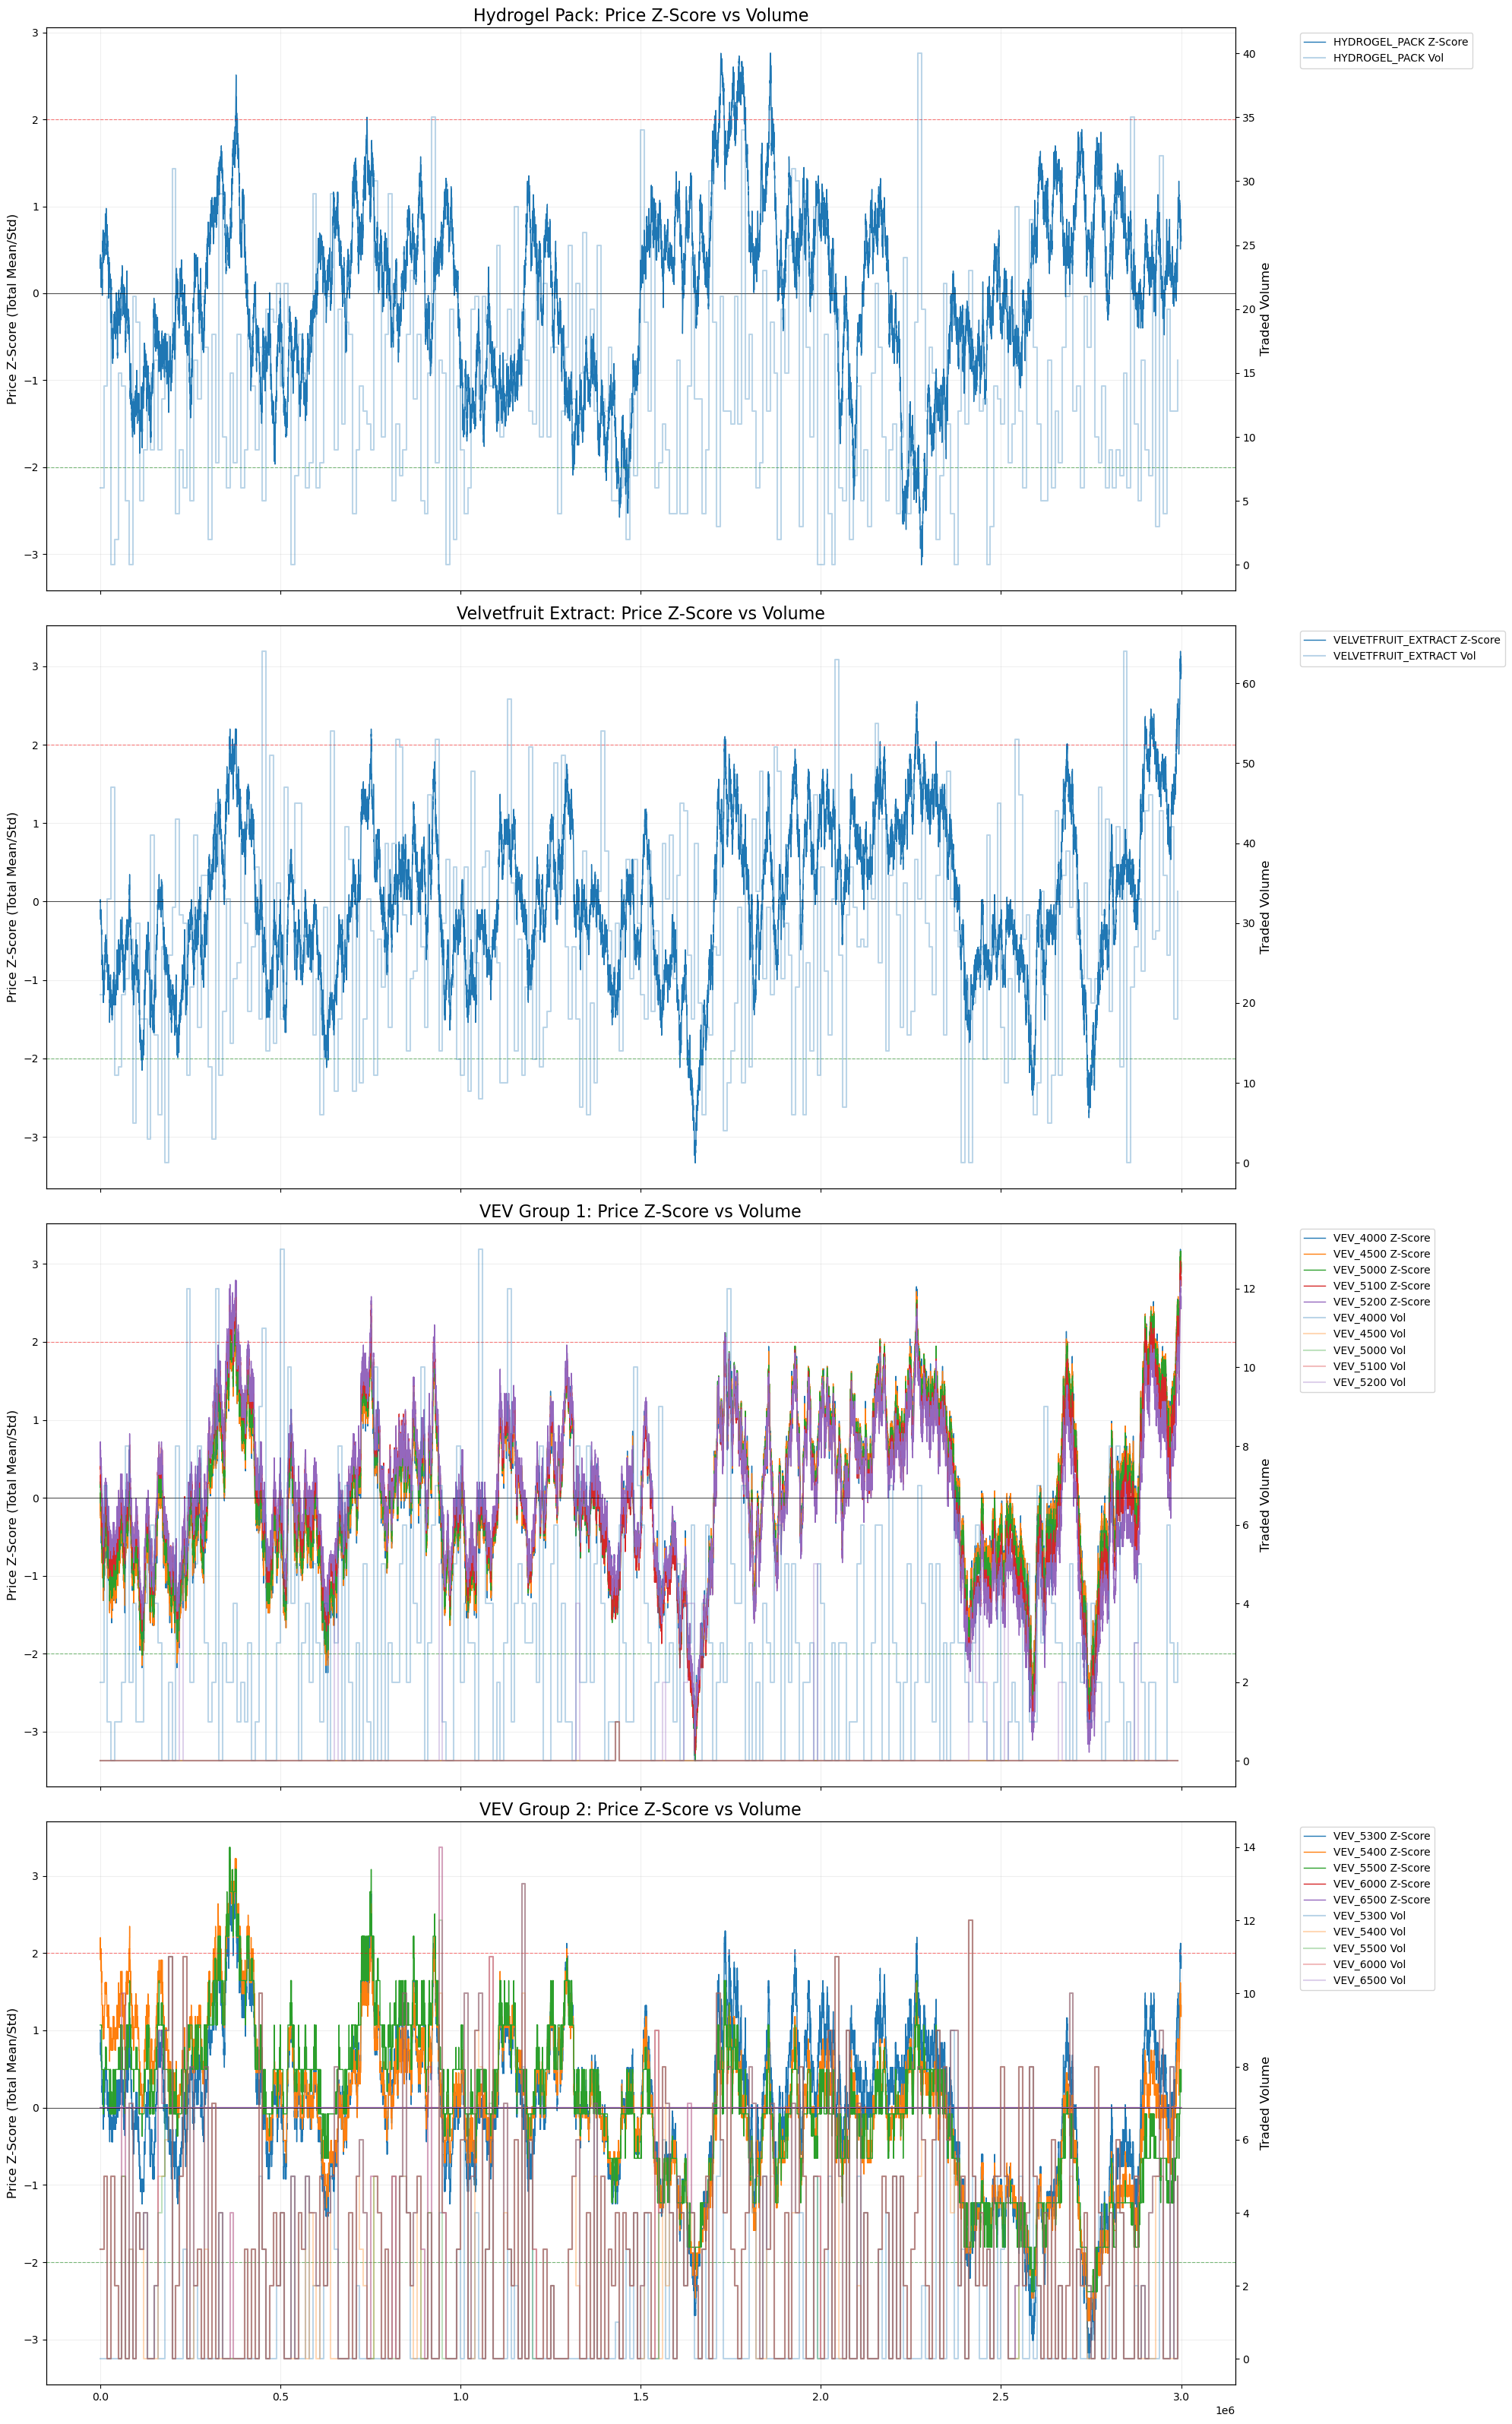

In [28]:
# Load and plot binned traded volume (right Y-axis) and Mid-Price Z-Score (left Y-axis)
trades_df = pd.read_csv(merged_tr_file, delimiter=";")
ob_df = pd.read_csv(merged_ob_file, delimiter=";")

# Bin settings
bin_window = 10000 
trades_df['time_bin'] = (trades_df['timestamp'] // bin_window) * bin_window

# Calculate binned volume
binned_volume = trades_df.groupby(["time_bin", "symbol"])["quantity"].sum().unstack(fill_value=0)

# Calculate mid-price for all products in ob_df
ob_df['best_bid'] = ob_df[['bid_price_1', 'bid_price_2', 'bid_price_3']].max(axis=1)
ob_df['best_ask'] = ob_df[['ask_price_1', 'ask_price_2', 'ask_price_3']].min(axis=1)
ob_df['mid_price'] = (ob_df['best_bid'] + ob_df['best_ask']) / 2

# Calculate Global Z-Score for each product's price
price_stats = ob_df.groupby('product')['mid_price'].agg(['mean', 'std']).to_dict('index')

def get_z_score(row):
    stats = price_stats.get(row['product'])
    if stats and stats['std'] > 0:
        return (row['mid_price'] - stats['mean']) / stats['std']
    return 0

ob_df['price_zscore'] = ob_df.apply(get_z_score, axis=1)

# Categorize products for plotting
all_products = binned_volume.columns.tolist()
hydro_product = [c for c in all_products if 'HYDROGEL' in c]
velvet_product = [c for c in all_products if 'VELVETFRUIT' in c]
vev_cols = [c for c in all_products if 'VEV' in c]
vev_1 = vev_cols[:len(vev_cols)//2]
vev_2 = vev_cols[len(vev_cols)//2:]

def plot_group(ax_left, products, title):
    ax_right = ax_left.twinx()
    
    # Plot Volume (Right Axis) - steps
    for product in products:
        if product in binned_volume.columns:
            ax_right.plot(binned_volume.index, binned_volume[product], 
                        label=f"{product} Vol", lw=1.5, drawstyle='steps-post', alpha=0.3)
    
    # Plot Price Z-Score (Left Axis) - lines
    for product in products:
        prod_data = ob_df[ob_df['product'] == product]
        if not prod_data.empty:
            ax_left.plot(prod_data['timestamp'], prod_data['price_zscore'], 
                       label=f"{product} Z-Score", lw=1.0)
            
    ax_left.set_title(title, fontsize=16)
    ax_left.set_ylabel("Price Z-Score (Total Mean/Std)", fontsize=12)
    ax_right.set_ylabel("Traded Volume", fontsize=12)
    
    # Add Z-Score reference lines
    ax_left.axhline(0, color='black', lw=0.5, linestyle='-')
    ax_left.axhline(2, color='red', lw=0.8, linestyle='--', alpha=0.5)
    ax_left.axhline(-2, color='green', lw=0.8, linestyle='--', alpha=0.5)
    
    # Combine legends
    lines_l, labels_l = ax_left.get_legend_handles_labels()
    lines_r, labels_r = ax_right.get_legend_handles_labels()
    ax_left.legend(lines_l + lines_r, labels_l + labels_r, loc='upper left', bbox_to_anchor=(1.05, 1))
    ax_left.grid(True, alpha=0.2)
    return ax_right

# Increased figsize for more detail and added one more subplot
fig, axes = plt.subplots(4, 1, figsize=(20, 32), sharex=True)

plot_group(axes[0], hydro_product, "Hydrogel Pack: Price Z-Score vs Volume")
plot_group(axes[1], velvet_product, "Velvetfruit Extract: Price Z-Score vs Volume")
plot_group(axes[2], vev_1, "VEV Group 1: Price Z-Score vs Volume")
plot_group(axes[3], vev_2, "VEV Group 2: Price Z-Score vs Volume")

plt.xlabel("Timestamp", fontsize=14)
plt.tight_layout()
plt.show()

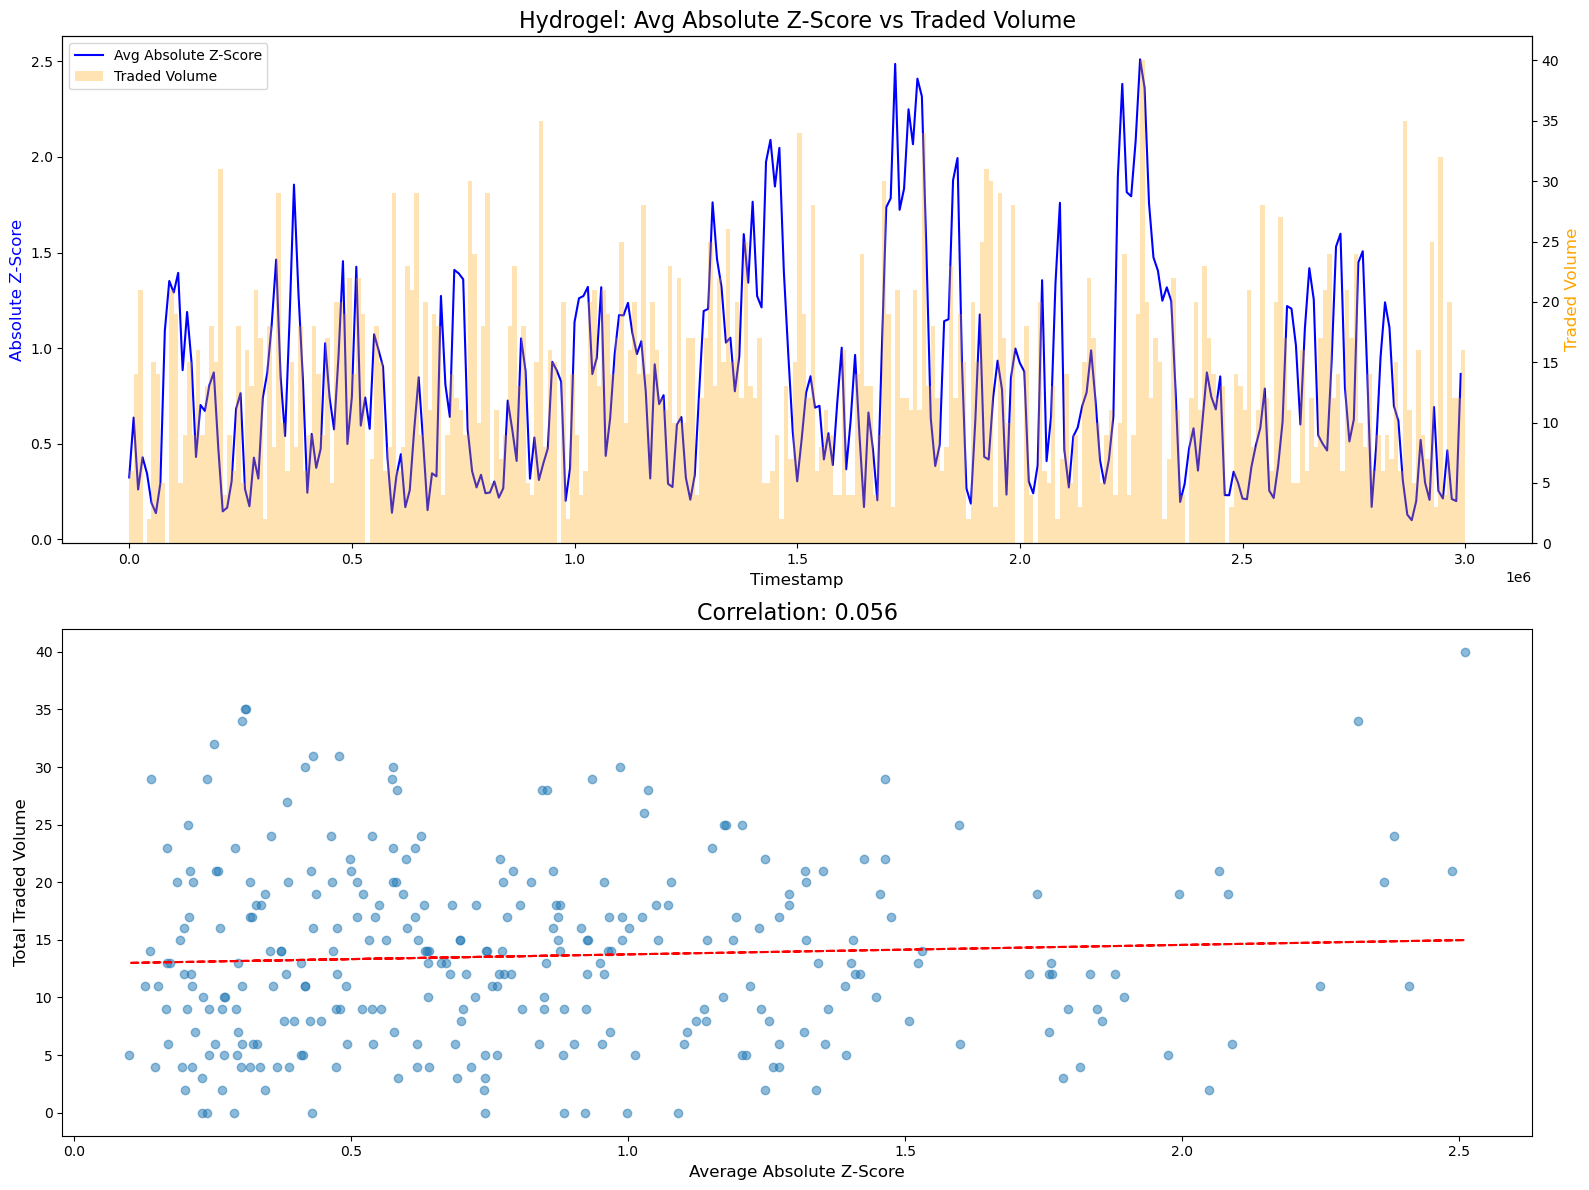

In [29]:
# Analysis of Absolute Z-Score vs Traded Volume for HYDROGEL_PACK

# 1. Prepare Data
# Get Hydrogel specific data
hydro_ob = ob_df[ob_df['product'] == 'HYDROGEL_PACK'].copy()
hydro_tr = trades_df[trades_df['symbol'] == 'HYDROGEL_PACK'].copy()

# Use the same binning strategy for comparison
bin_window = 10000 
hydro_ob['time_bin'] = (hydro_ob['timestamp'] // bin_window) * bin_window
hydro_tr['time_bin'] = (hydro_tr['timestamp'] // bin_window) * bin_window

# Calculate average absolute Z-score per bin
bin_z_abs = hydro_ob.groupby('time_bin')['price_zscore'].apply(lambda x: x.abs().mean())

# Calculate total volume per bin
bin_vol = hydro_tr.groupby('time_bin')['quantity'].sum()

# Merge for correlation analysis
correlation_df = pd.DataFrame({
    'abs_zscore': bin_z_abs,
    'volume': bin_vol
}).fillna(0)

# 2. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Graph 1: Time Series of Absolute Z-Score and Volume
ax1_right = ax1.twinx()
ax1.plot(correlation_df.index, correlation_df['abs_zscore'], color='blue', label='Avg Absolute Z-Score', lw=1.5)
ax1_right.bar(correlation_df.index, correlation_df['volume'], width=bin_window, color='orange', alpha=0.3, label='Traded Volume', align='edge')

ax1.set_title("Hydrogel: Avg Absolute Z-Score vs Traded Volume", fontsize=16)
ax1.set_ylabel("Absolute Z-Score", fontsize=12, color='blue')
ax1_right.set_ylabel("Traded Volume", fontsize=12, color='orange')
ax1.set_xlabel("Timestamp", fontsize=12)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_right.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Graph 2: Scatter Plot & Correlation
ax2.scatter(correlation_df['abs_zscore'], correlation_df['volume'], alpha=0.5)
m, b = np.polyfit(correlation_df['abs_zscore'], correlation_df['volume'], 1)
ax2.plot(correlation_df['abs_zscore'], m * correlation_df['abs_zscore'] + b, color='red', linestyle='--')

corr_value = correlation_df['abs_zscore'].corr(correlation_df['volume'])
ax2.set_title(f"Correlation: {corr_value:.3f}", fontsize=16)
ax2.set_xlabel("Average Absolute Z-Score", fontsize=12)
ax2.set_ylabel("Total Traded Volume", fontsize=12)

plt.tight_layout()
plt.show()

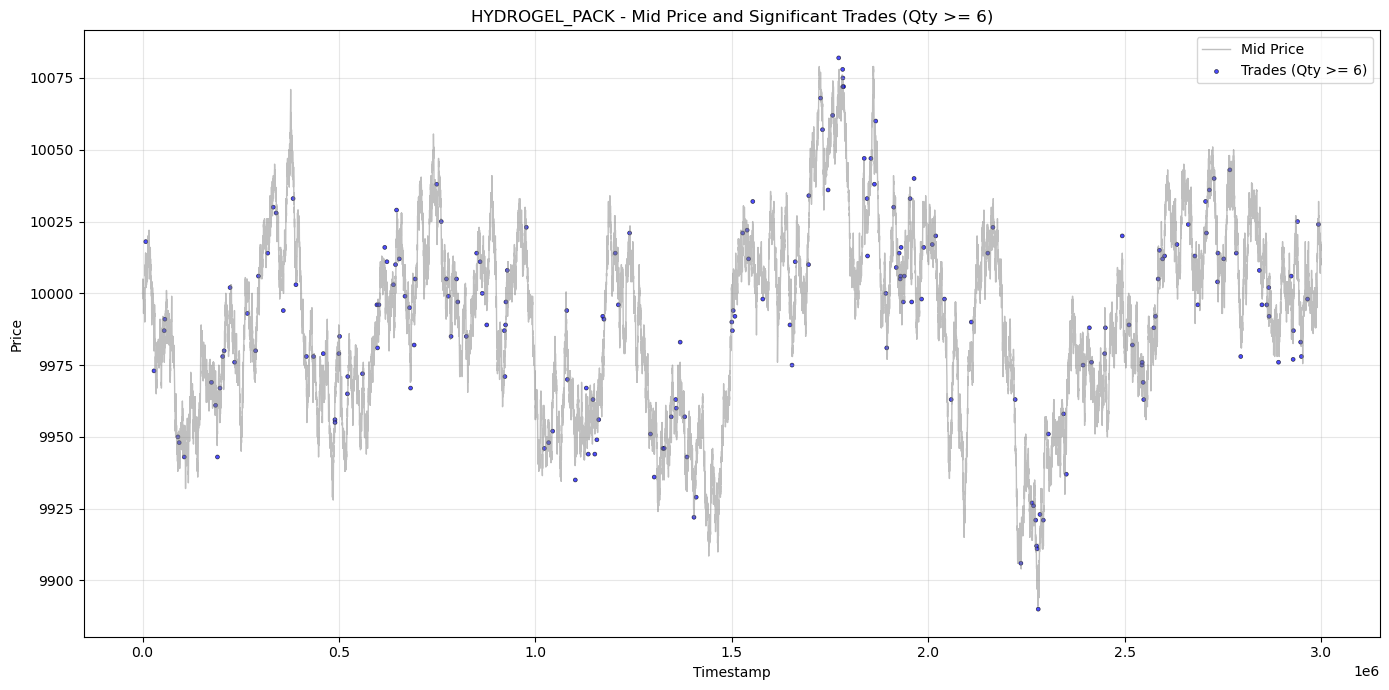

In [30]:
# Configuration
VOLUME_THRESHOLD = 6
product_name = 'HYDROGEL_PACK'

# Filter product specific data
product_ob = ob_df[ob_df['product'] == product_name].copy()
product_tr = trades_df[(trades_df['symbol'] == product_name) & (trades_df['quantity'] >= VOLUME_THRESHOLD)].copy()

plt.figure(figsize=(14, 7))

# Plot Mid-Price
plt.plot(product_ob['timestamp'], product_ob['mid_price'], label='Mid Price', color='gray', alpha=0.5, lw=1)

# Plot Trades as dots with size representing volume
if not product_tr.empty:
	plt.scatter(
		product_tr['timestamp'], 
		product_tr['price'], 
		s=(product_tr['quantity'] - VOLUME_THRESHOLD + 1) * 8,  # Scale size for visibility
		c='blue', 
		alpha=0.7, 
		label=f'Trades (Qty >= {VOLUME_THRESHOLD})',
		edgecolors='black',
		linewidths=0.5
	)

plt.title(f'{product_name} - Mid Price and Significant Trades (Qty >= {VOLUME_THRESHOLD})')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

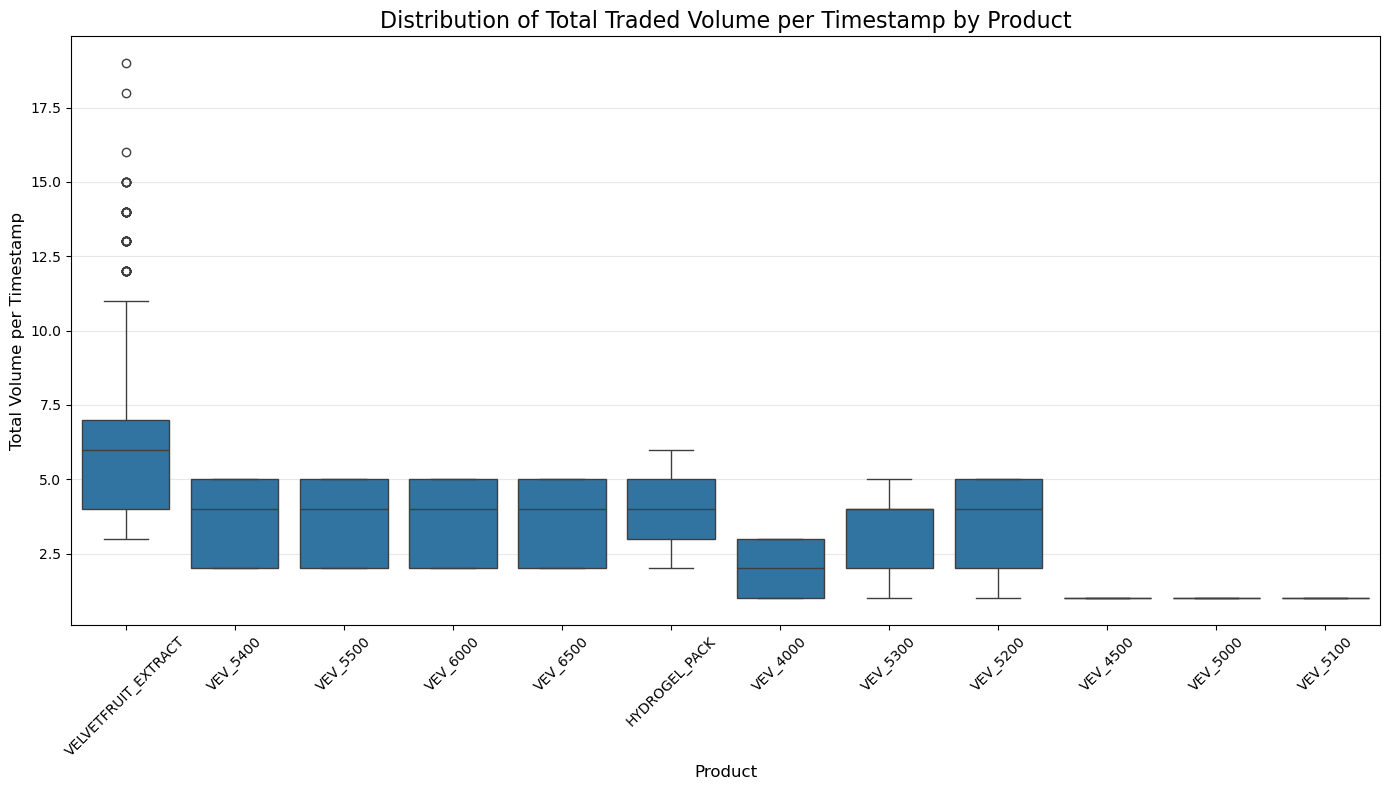

Summary Statistics of Volume per Timestamp:
                      count      mean       std  min  25%  50%  75%   max
symbol                                                                   
HYDROGEL_PACK        1010.0  4.037624  1.408093  2.0  3.0  4.0  5.0   6.0
VELVETFRUIT_EXTRACT  1363.0  6.066764  2.337670  3.0  4.0  6.0  7.0  19.0
VEV_4000              464.0  2.025862  0.809887  1.0  1.0  2.0  3.0   3.0
VEV_4500                1.0  1.000000       NaN  1.0  1.0  1.0  1.0   1.0
VEV_5000                1.0  1.000000       NaN  1.0  1.0  1.0  1.0   1.0
VEV_5100                1.0  1.000000       NaN  1.0  1.0  1.0  1.0   1.0
VEV_5200               18.0  3.500000  1.382666  1.0  2.0  4.0  5.0   5.0
VEV_5300              121.0  3.471074  1.148001  1.0  2.0  4.0  4.0   5.0
VEV_5400              225.0  3.497778  1.146129  2.0  2.0  4.0  5.0   5.0
VEV_5500              267.0  3.509363  1.144990  2.0  2.0  4.0  5.0   5.0
VEV_6000              284.0  3.528169  1.144621  2.0  2.0  4.0  5.0 

In [31]:
# Distribution of volumes traded per timestamp, grouped by product
import seaborn as sns

# Aggregate trades: sum volume per timestamp per symbol
aggregated_trades = trades_df.groupby(['timestamp', 'symbol'])['quantity'].sum().reset_index()

plt.figure(figsize=(14, 8))

# Create a boxplot or violin plot to show distribution
# Note: Log scale might be useful if volumes vary significantly
sns.boxplot(data=aggregated_trades, x='symbol', y='quantity')

plt.title('Distribution of Total Traded Volume per Timestamp by Product', fontsize=16)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Total Volume per Timestamp', fontsize=12)
plt.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print summary statistics for verification
print("Summary Statistics of Volume per Timestamp:")
print(aggregated_trades.groupby('symbol')['quantity'].describe())

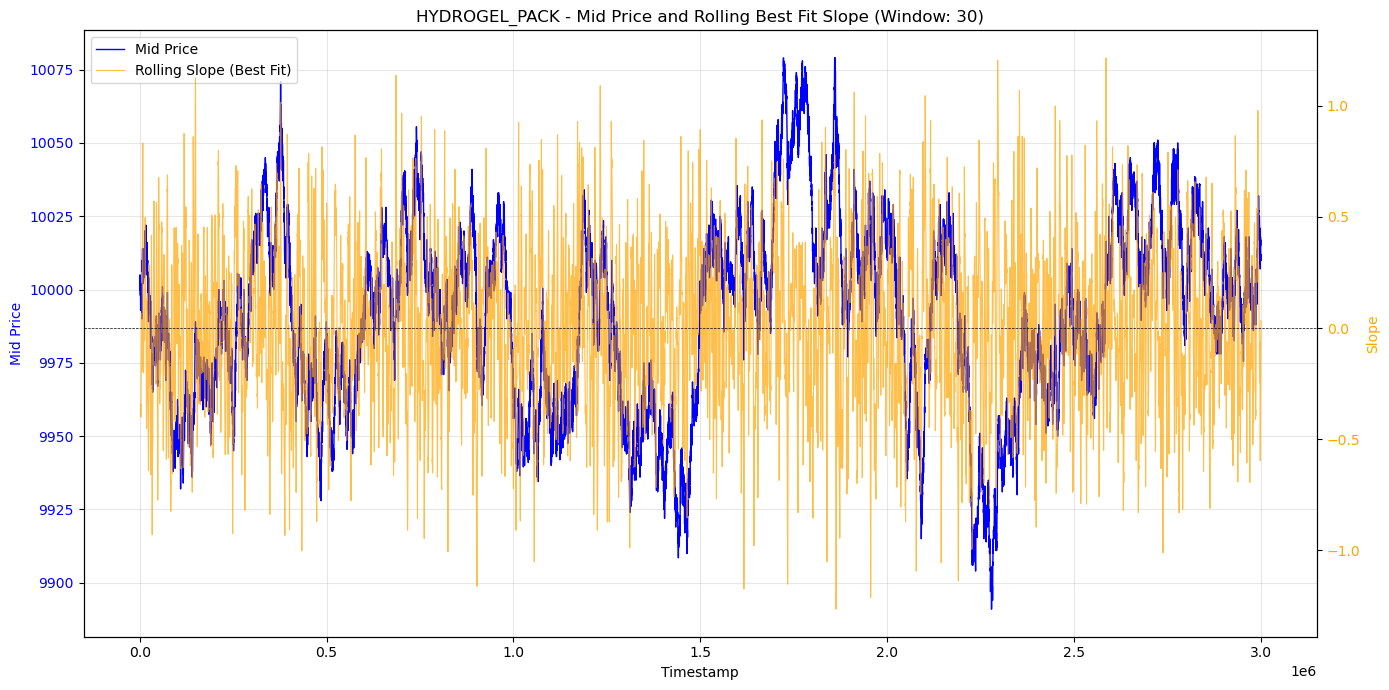

In [32]:
# Calculate rolling slope for HYDROGEL_PACK using the defined ROLLING_WINDOW
def get_rolling_slope(window_data):
	if len(window_data) < ROLLING_WINDOW:
		return np.nan
	x = np.arange(len(window_data))
	m, b = np.polyfit(x, window_data, 1)
	return m

# Using product_ob which already contains HYDROGEL_PACK filtered data from previous cells
product_ob['rolling_slope'] = product_ob['mid_price'].rolling(window=ROLLING_WINDOW).apply(get_rolling_slope)

fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Mid Price
ax1.plot(product_ob['timestamp'], product_ob['mid_price'], label='Mid Price', color='blue', lw=1)
ax1.set_ylabel('Mid Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot Rolling Slope on a secondary Y-axis
ax2 = ax1.twinx()
ax2.plot(product_ob['timestamp'], product_ob['rolling_slope'], label='Rolling Slope (Best Fit)', color='orange', lw=0.8, alpha=0.7)
ax2.axhline(0, color='black', linestyle='--', lw=0.5)
ax2.set_ylabel('Slope', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title(f'{product_name} - Mid Price and Rolling Best Fit Slope (Window: {ROLLING_WINDOW})')
ax1.set_xlabel('Timestamp')
ax1.grid(True, alpha=0.3)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()